In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pydose_rt as PDRT


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

In [2]:
machine_config = PDRT.MachineConfig(number_of_leaf_pairs=10, tpr_20_10=0.73, mean_photon_energy_MeV=0.39)
phantom = PDRT.Phantom.from_uniform_water(shape=(100, 100, 100), spacing=(2.0, 2.0, 2.0))
beam = PDRT.Beam.create(
    gantry_angle_deg=0.0,
    number_of_leaf_pairs=10, 
    field_size_mm=(100.0, 100.0),
    iso_center=(100.0, 100.0, 100.0)
)
engine = PDRT.DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=phantom.resolution,
    dose_grid_shape=phantom.density_image.shape,
    kernel_size=75,
    beam_template=beam,
    device=device,
    dtype=dtype)
engine.calibrate(110)
phantom = phantom.to(engine.dtype).to(engine.device)
beam = beam.to(engine.device).to(engine.dtype)
dose_lr = engine.compute_dose(beam, density_image=phantom.density_image).detach().cpu().numpy()

Calibration failed. Adjusting calibration factor to: 0.0024925573985071204


/home/bolo/Documents/PyDoseRT/src/pydose_rt/geometry/projections.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  leaf_widths = torch.tensor(


In [3]:
machine_config = PDRT.MachineConfig(number_of_leaf_pairs=10, tpr_20_10=0.73, mean_photon_energy_MeV=0.39)
phantom = PDRT.Phantom.from_uniform_water(shape=(200, 200, 200), spacing=(1.0, 1.0, 1.0))
beam = PDRT.Beam.create(
    gantry_angle_deg=0.0,
    number_of_leaf_pairs=10, 
    field_size_mm=(100.0, 100.0),
    iso_center=(100.0, 100.0, 100.0)
)
engine = PDRT.DoseEngine(
    machine_config=machine_config,
    dose_grid_spacing=phantom.resolution,
    dose_grid_shape=phantom.density_image.shape,
    beam_template=beam,
    kernel_size=151,
    device=device,
    dtype=dtype)
engine.calibrate(110)
phantom = phantom.to(engine.dtype).to(engine.device)
beam = beam.to(engine.device).to(engine.dtype)
dose_hr = engine.compute_dose(beam, density_image=phantom.density_image).detach().cpu().numpy()


Calibration failed. Adjusting calibration factor to: 0.0013316409673578367


/tmp/ipykernel_3623402/3779828699.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


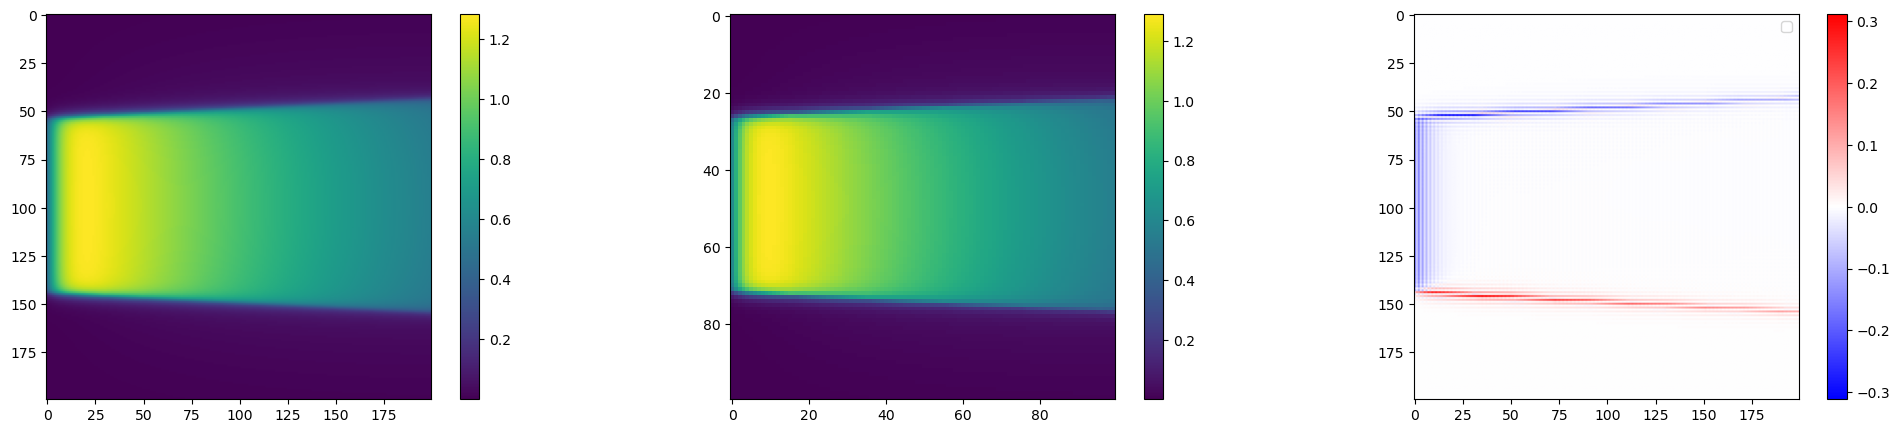

In [4]:
slice_idx = 0
slice_idx_hr = 100 + slice_idx * 2
slice_idx_lr = 50 + slice_idx

plt.figure(figsize=(25, 5))
plt.subplot(131)
plt.imshow(100 * dose_hr[0, :, :, slice_idx_hr], label='high res')
plt.colorbar()
plt.subplot(132)
plt.imshow(100 * dose_lr[0, :, :, slice_idx_lr], label='low res')
plt.colorbar()
plt.subplot(133)
immax = np.max(np.abs(100 * dose_hr[0, :, :, slice_idx_hr] - np.repeat(np.repeat(100 * dose_lr[0, :, :, slice_idx_lr], 2, axis=1), 2, axis=0)))
plt.imshow(100 * dose_hr[0, :, :, slice_idx_hr] - np.repeat(np.repeat(100 * dose_lr[0, :, :, slice_idx_lr], 2, axis=1), 2, axis=0), cmap='bwr', vmin=-immax, vmax=immax)
plt.colorbar()
plt.legend()

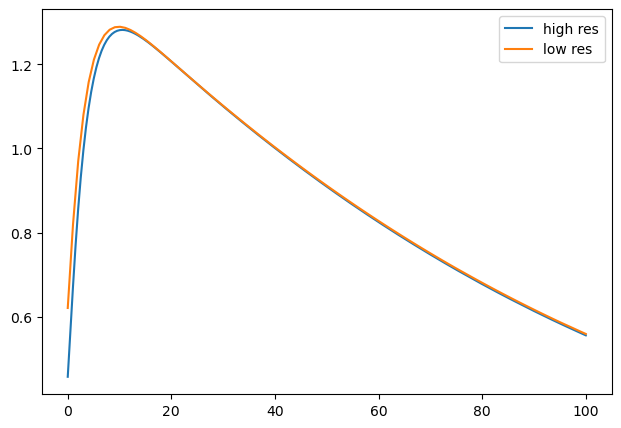

In [5]:
slice_idx = 0
slice_idx_hr = 100 + slice_idx * 2
slice_idx_lr = 50 + slice_idx

plt.figure(figsize=(25, 5))
plt.subplot(131)
plt.plot(np.linspace(0, 100, dose_hr.shape[2]), 100 * dose_hr[0, 100, :, slice_idx_hr], label='high res')
plt.plot(np.linspace(0, 100, dose_lr.shape[2]), 100 * dose_lr[0, 50, :, slice_idx_lr], label='low res')
plt.legend()

/tmp/ipykernel_3623402/1532187851.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


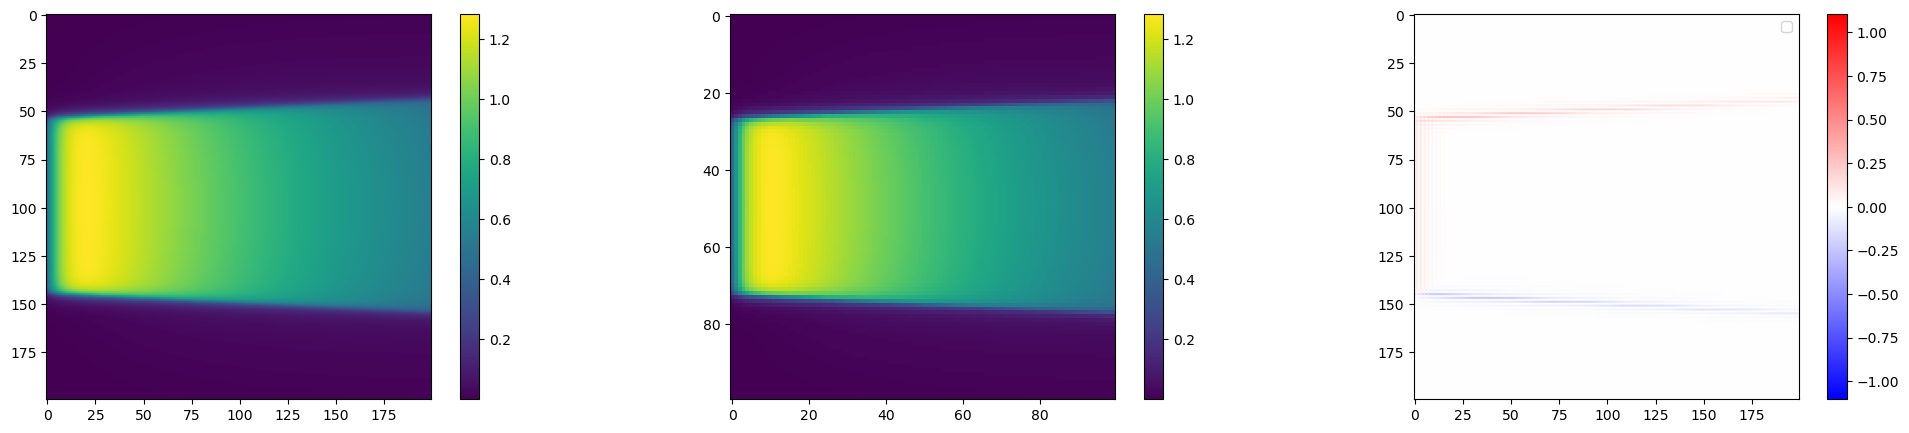

In [6]:
slice_idx = 0
slice_idx_hr = 100 + slice_idx * 2
slice_idx_lr = 50 + slice_idx

plt.figure(figsize=(25, 5))
plt.subplot(131)
plt.imshow(100 * dose_hr[0, :, :, slice_idx_hr], label='high res')
plt.colorbar()
plt.subplot(132)
plt.imshow(100 * dose_hr[0, ::2, ::2, slice_idx_hr], label='low res')
plt.colorbar()
plt.subplot(133)
immax = np.max(np.abs(100 * dose_hr[0, :, :, slice_idx_hr] - np.repeat(np.repeat(100 * dose_hr[0, ::2, ::2, slice_idx_lr], 2, axis=1), 2, axis=0)))
plt.imshow(100 * dose_hr[0, :, :, slice_idx_hr] - np.repeat(np.repeat(100 * dose_hr[0, ::2, ::2, slice_idx_hr], 2, axis=1), 2, axis=0), cmap='bwr', vmin=-immax, vmax=immax)
plt.colorbar()
plt.legend()